In [1]:
pip install ta

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29497 sha256=b5a11909d58ddec4f3accfdb65e8ab4f7ff23a735b05f404f8110e15deef1ce6
  Stored in directory: c:\users\bochao.zhang\appdata\local\pip\cache\wheels\a1\d7\29\7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 用mplfinance画专业级图表，把所有指标整合在一起
# 今天的目标是做出一张真正可读的分析图——K线 + 成交量 + SMA/EMA + RSI，分成多个子图，这是后续做回测报告的基础模板。

In [2]:
import yfinance as yf
import pandas as pd
import mplfinance as mpf
import ta

df = yf.download("7203.T", start="2024-09-01", end="2025-03-01")
df.columns = df.columns.droplevel(1) if df.columns.nlevels > 1 else df.columns

# SMA / EMA
df["SMA5"]  = df["Close"].rolling(5).mean()
df["SMA25"] = df["Close"].rolling(25).mean()
df["EMA5"]  = df["Close"].ewm(span=5, adjust=False).mean()

# RSI（14日）
df["RSI14"] = ta.momentum.RSIIndicator(df["Close"], window=14).rsi()

# MACD
macd = ta.trend.MACD(df["Close"])
df["MACD"]        = macd.macd()
df["MACD_signal"] = macd.macd_signal()
df["MACD_hist"]   = macd.macd_diff()

print(df[["Close","SMA5","RSI14","MACD"]].tail(5))

[*********************100%***********************]  1 of 1 completed

Price             Close         SMA5      RSI14       MACD
Date                                                      
2025-02-21  2617.883545  2660.353955  38.110129 -37.403247
2025-02-25  2622.236816  2648.164209  38.634540 -40.896752
2025-02-26  2636.264648  2632.878662  40.387410 -42.048739
2025-02-27  2693.343506  2638.393066  47.018968 -37.918805
2025-02-28  2601.437012  2634.233105  39.415669 -41.582552


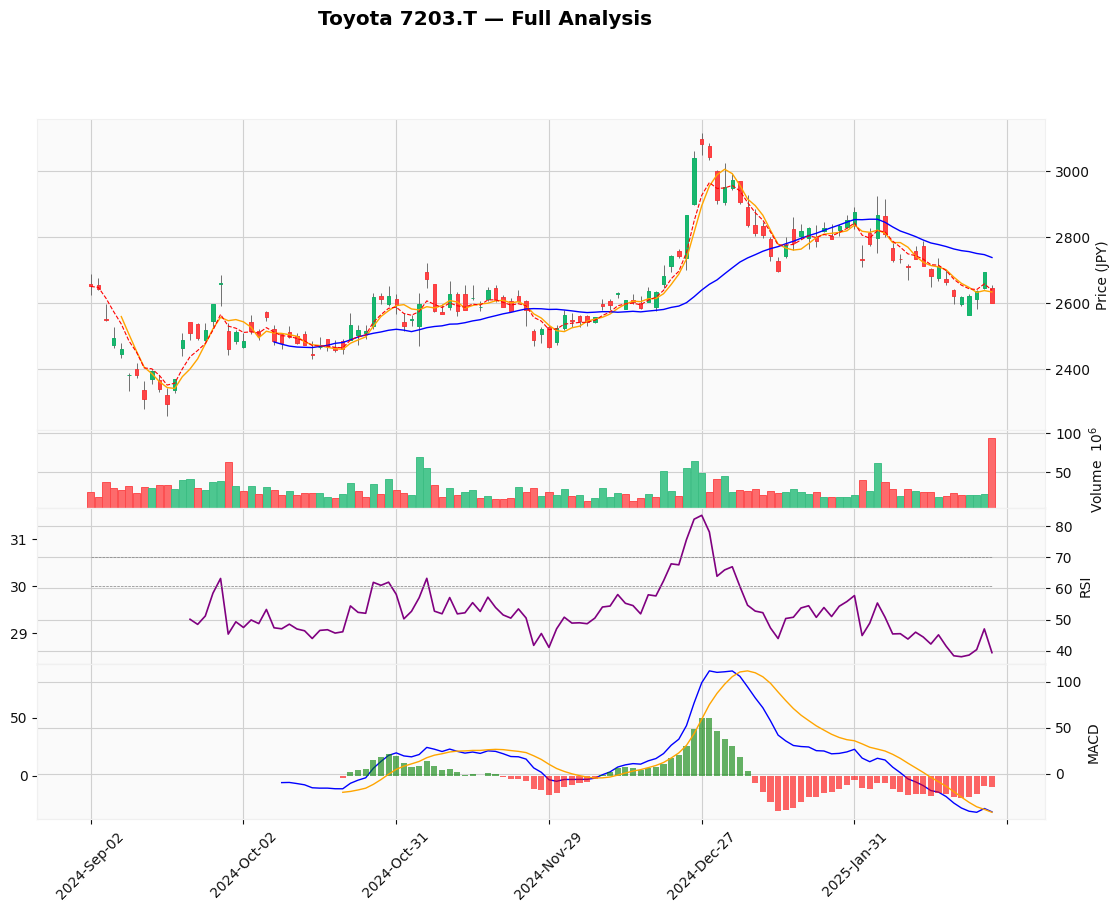

In [3]:
# RSI 超买超卖参考线
rsi_ob = [70] * len(df)   # 超买线
rsi_os = [30] * len(df)   # 超卖线

# MACD柱状图颜色（正值绿，负值红）
hist_colors = ["green" if v >= 0 else "red" 
               for v in df["MACD_hist"].fillna(0)]

add_plots = [
    # 均线
    mpf.make_addplot(df["SMA5"],  color="orange", width=1.0, panel=0),
    mpf.make_addplot(df["SMA25"], color="blue",   width=1.0, panel=0),
    mpf.make_addplot(df["EMA5"],  color="red",    width=0.8, panel=0, linestyle="dashed"),

    # RSI（panel=2，独立子图）
    mpf.make_addplot(df["RSI14"],              color="purple", width=1.2, panel=2, ylabel="RSI"),
    mpf.make_addplot(rsi_ob, color="gray", width=0.5, panel=2, linestyle="dashed"),
    mpf.make_addplot(rsi_os, color="gray", width=0.5, panel=2, linestyle="dashed"),

    # MACD线（panel=3）
    mpf.make_addplot(df["MACD"],        color="blue",  width=1.0, panel=3, ylabel="MACD"),
    mpf.make_addplot(df["MACD_signal"], color="orange",width=1.0, panel=3),
    mpf.make_addplot(df["MACD_hist"],   type="bar",    panel=3,
                     color=hist_colors, alpha=0.6),
]

mpf.plot(
    df,
    type="candle",
    volume=True,          # panel=1（成交量）
    addplot=add_plots,
    style="yahoo",
    title="Toyota 7203.T — Full Analysis",
    ylabel="Price (JPY)",
    figsize=(14, 10),
    panel_ratios=(4, 1, 2, 2),   # 各子图高度比例
)